# Notebook 06 — SHAP & LIME Explainability: Hospital Readmission Risk (Case 2)

Generates global and local explanations for the 30-day readmission model using SHAP and LIME.

**Requires**: Run notebooks 04 and 05 first.

**Outputs saved**:
- `shap_explainer_case2.pkl` — SHAP TreeExplainer for the best model (LightGBM or XGBoost)
- `lime_config_case2.pkl` — LIME LimeTabularExplainer
- `shap_values_case2.pkl` — precomputed SHAP values on test set

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings

import shap
import lime
import lime.lime_tabular

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
shap.initjs()

RANDOM_STATE = 42
MODELS_DIR = '../models/'

## 1. Load Artifacts

In [55]:
# ReadmissionPreprocessor must be defined here so pickle can deserialize it
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

class ReadmissionPreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.numeric_cols_ = None
        self.imputer_ = SimpleImputer(strategy='median')
        self.scaler_ = StandardScaler()
        self.feature_names_ = None

    def fit(self, X, y=None):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        self.feature_names_ = list(X.columns)
        base_numeric = [
            'age_numeric', 'time_in_hospital', 'num_lab_procedures',
            'num_procedures', 'num_medications', 'number_diagnoses',
            'number_outpatient', 'number_emergency', 'number_inpatient',
            'A1Cresult', 'max_glu_serum',
            'num_prior_visits', 'inpatient_ratio',
            'total_meds_prescribed', 'total_med_changes',
            'procedures_per_day', 'labs_per_day', 'meds_per_day',
        ]
        self.numeric_cols_ = [c for c in base_numeric if c in X.columns]
        self.imputer_.fit(X[self.numeric_cols_])
        self.scaler_.fit(self.imputer_.transform(X[self.numeric_cols_]))
        return self

    def transform(self, X, y=None):
        X = pd.DataFrame(X).copy() if not isinstance(X, pd.DataFrame) else X.copy()
        scaled = self.scaler_.transform(self.imputer_.transform(X[self.numeric_cols_]))
        X[self.numeric_cols_] = scaled
        return X.values

    def get_feature_names_out(self):
        return self.feature_names_

print('ReadmissionPreprocessor defined.')


ReadmissionPreprocessor defined.


In [56]:
with open(MODELS_DIR + 'processed_data_case2.pkl', 'rb') as f:
    data = pickle.load(f)

with open(MODELS_DIR + 'best_model_case2.pkl', 'rb') as f:
    model = pickle.load(f)

with open(MODELS_DIR + 'preprocessor_case2.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

X_train_bal = data['X_train_bal']
X_test_proc = data['X_test_proc']
X_test = data['X_test']          # original (unscaled) DataFrame — used for LIME
y_test = data['y_test']
feature_names = data['feature_names']

print('Model:', type(model).__name__)
print('Test set shape:', X_test_proc.shape)
print('Features:', len(feature_names))

Model: LGBMClassifier
Test set shape: (13998, 207)
Features: 207


## 2. SHAP — Global Explanations

In [57]:
# TreeExplainer works for both XGBoost and LightGBM
# feature_perturbation='tree_path_dependent' is required for LightGBM
shap_explainer = shap.TreeExplainer(
    model,
    feature_perturbation='tree_path_dependent'
)

# Compute SHAP values on test set (sample for speed)
N_SHAP = min(2000, X_test_proc.shape[0])
np.random.seed(RANDOM_STATE)
shap_idx = np.random.choice(X_test_proc.shape[0], N_SHAP, replace=False)
X_shap_sample = X_test_proc[shap_idx]
y_shap_sample = y_test.iloc[shap_idx] if hasattr(y_test, 'iloc') else y_test[shap_idx]

shap_values = shap_explainer.shap_values(X_shap_sample)
# LightGBM returns list [neg_class, pos_class]; XGBoost returns 2D array
if isinstance(shap_values, list):
    shap_vals_pos = shap_values[1]
else:
    shap_vals_pos = shap_values

print('SHAP values shape:', shap_vals_pos.shape)
print('Model type:', type(model).__name__)


SHAP values shape: (2000, 207)
Model type: LGBMClassifier


### 2.1 SHAP Summary Plot (Beeswarm)

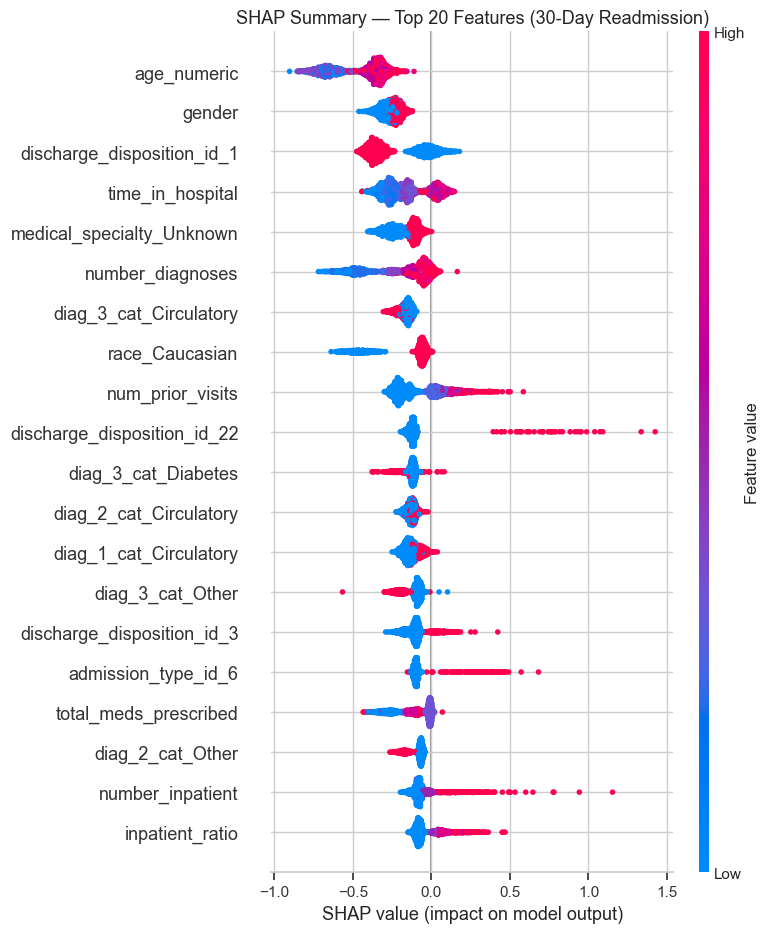

In [58]:
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_vals_pos, X_shap_sample,
    feature_names=feature_names,
    max_display=20,
    show=False
)
plt.title('SHAP Summary — Top 20 Features (30-Day Readmission)', fontsize=13)
plt.tight_layout()
plt.show()

### 2.2 SHAP Bar Plot (Mean |SHAP|)

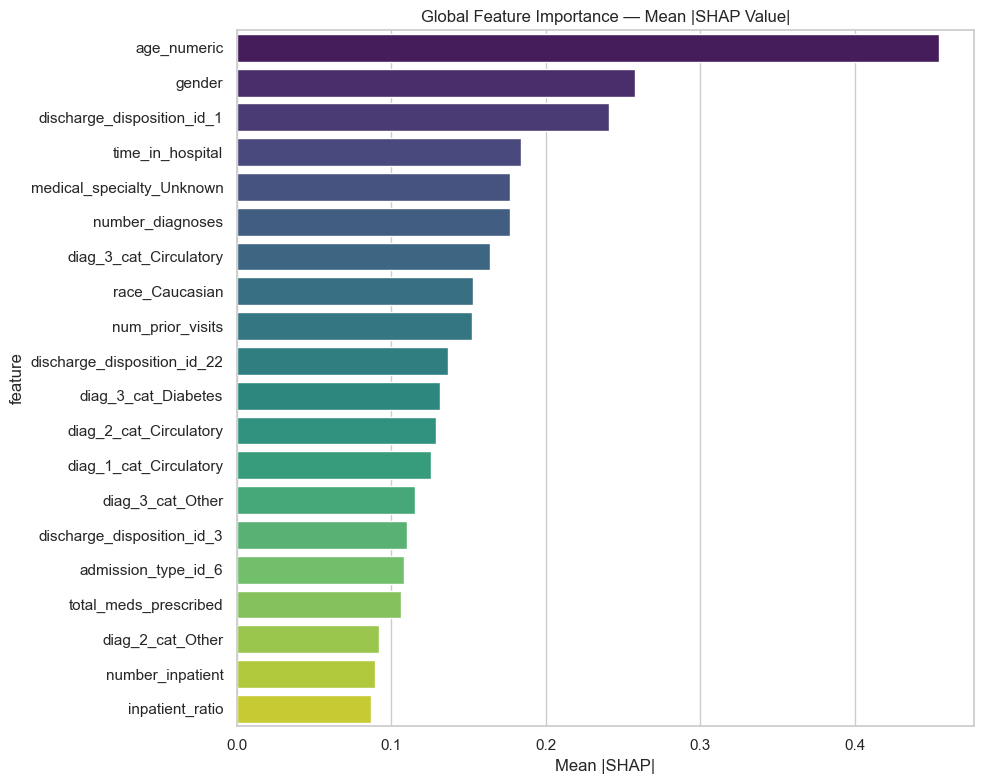

In [59]:
mean_abs_shap = np.abs(shap_vals_pos).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': mean_abs_shap
}).sort_values('mean_abs_shap', ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=shap_importance, x='mean_abs_shap', y='feature', palette='viridis')
plt.title('Global Feature Importance — Mean |SHAP Value|')
plt.xlabel('Mean |SHAP|')
plt.tight_layout()
plt.show()

### 2.3 SHAP Dependence Plots — Top 4 Features

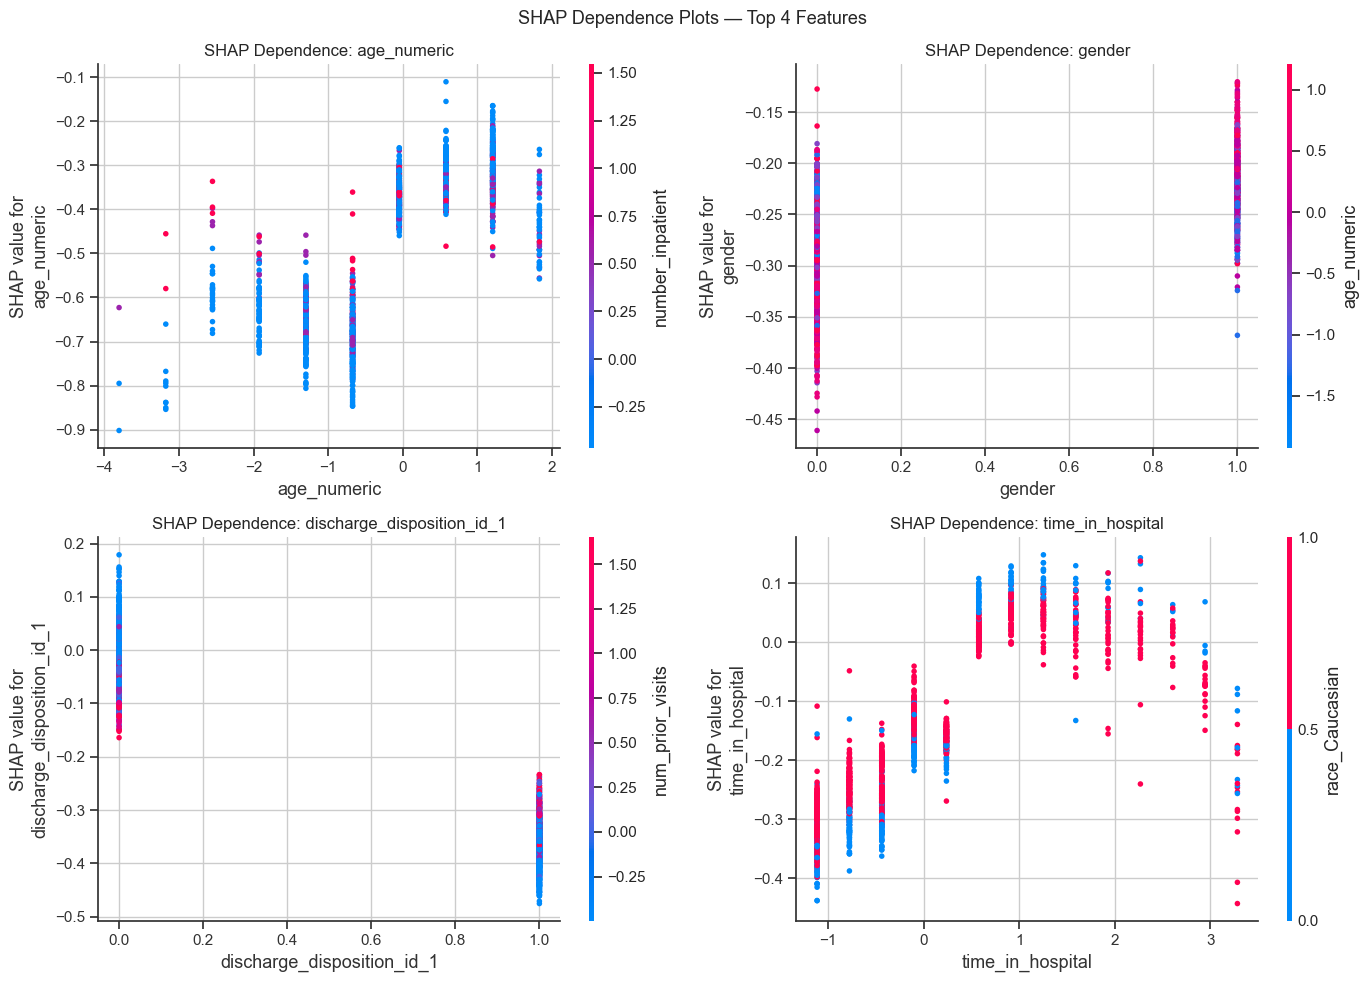

In [60]:
top4_features = shap_importance['feature'].head(4).tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top4_features):
    feat_idx = feature_names.index(feat)
    plt.sca(axes[i])
    shap.dependence_plot(
        feat_idx, shap_vals_pos, X_shap_sample,
        feature_names=feature_names,
        ax=axes[i], show=False
    )
    axes[i].set_title(f'SHAP Dependence: {feat}')

plt.suptitle('SHAP Dependence Plots — Top 4 Features', fontsize=13)
plt.tight_layout()
plt.show()

### 2.4 SHAP Waterfall — Single High-Risk Patient

Patient index: 15
True label: 1
Predicted probability: 0.4158


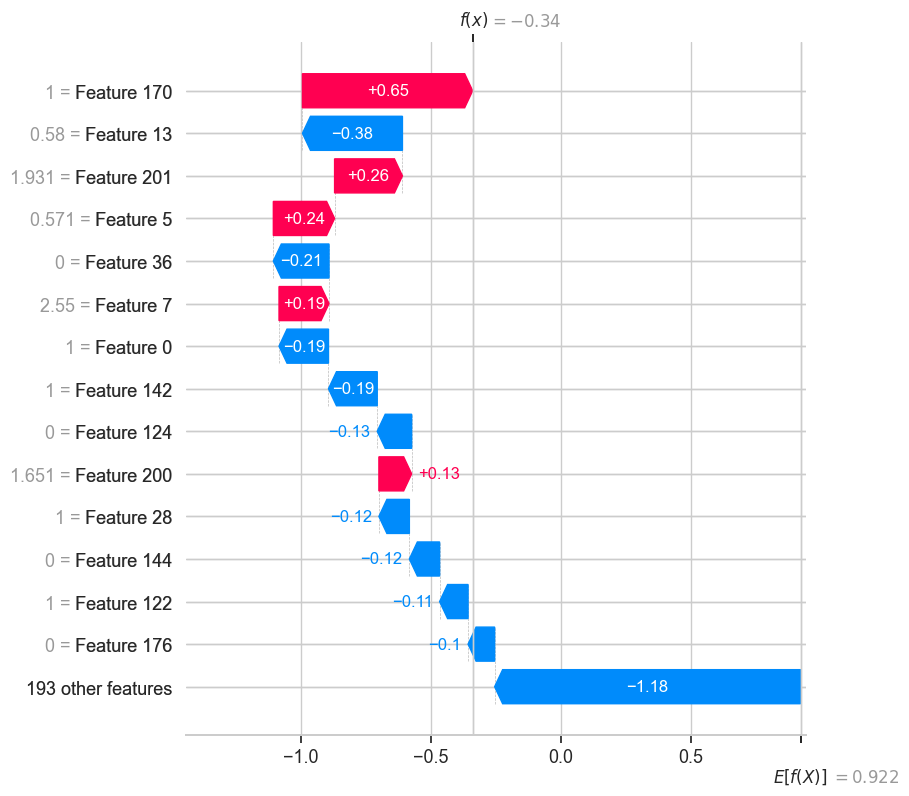

In [61]:
# Find a true positive (actually readmitted, predicted high risk)
y_shap_arr = np.array(y_shap_sample)
proba = model.predict_proba(X_shap_sample)[:, 1]
tp_mask = (y_shap_arr == 1) & (proba > 0.3)  # lower threshold since opt_threshold ~0.15

if tp_mask.sum() > 0:
    patient_idx = np.where(tp_mask)[0][0]
else:
    patient_idx = np.argmax(proba)  # fallback: highest predicted risk

print(f'Patient index: {patient_idx}')
print(f'True label: {y_shap_arr[patient_idx]}')
print(f'Predicted probability: {proba[patient_idx]:.4f}')

# SHAP Explanation object for waterfall — use check_additivity=False for LightGBM
explainer_obj = shap.TreeExplainer(
    model, feature_perturbation='tree_path_dependent'
)
single_shap = explainer_obj(
    X_shap_sample[patient_idx:patient_idx+1],
    check_additivity=False
)
# For LightGBM the Explanation object may be indexed differently
shap_exp = single_shap[..., 1] if single_shap.values.ndim == 3 else single_shap
shap.plots.waterfall(shap_exp[0], max_display=15, show=True)


### 2.5 SHAP Waterfall — Single Low-Risk Patient

Low-risk patient index: 0
True label: 0
Predicted probability: 0.0394


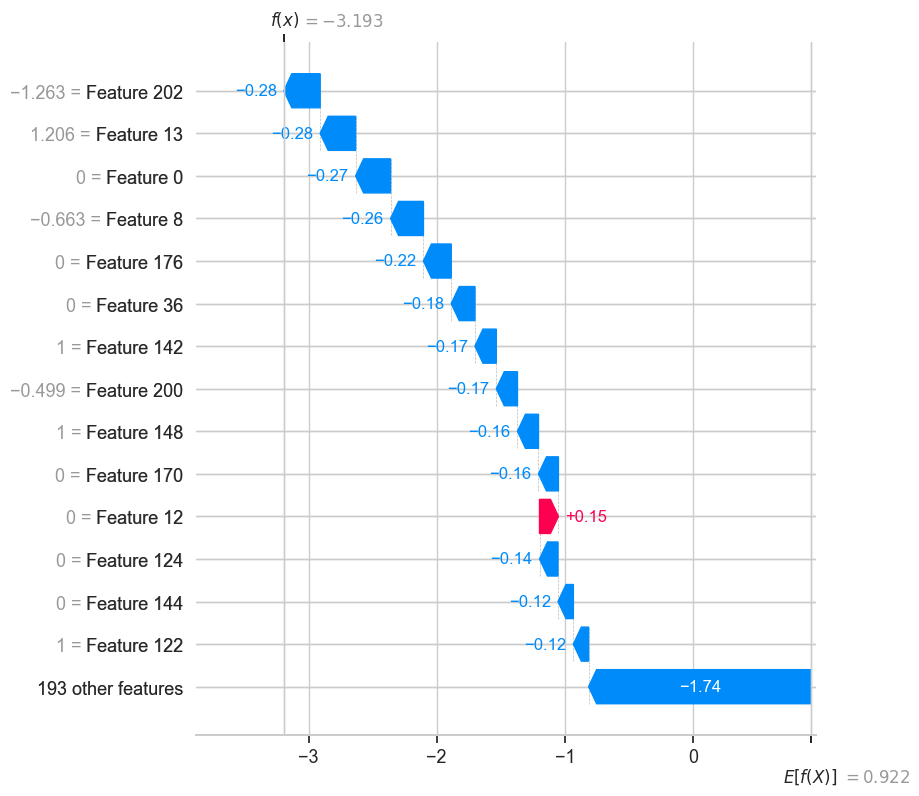

In [62]:
# Find a true negative (not readmitted, predicted low risk)
tn_mask = (y_shap_arr == 0) & (proba < 0.1)
if tn_mask.sum() > 0:
    low_risk_idx = np.where(tn_mask)[0][0]
else:
    low_risk_idx = np.argmin(proba)

print(f'Low-risk patient index: {low_risk_idx}')
print(f'True label: {y_shap_arr[low_risk_idx]}')
print(f'Predicted probability: {proba[low_risk_idx]:.4f}')

single_shap_low = explainer_obj(
    X_shap_sample[low_risk_idx:low_risk_idx+1],
    check_additivity=False
)
shap_exp_low = single_shap_low[..., 1] if single_shap_low.values.ndim == 3 else single_shap_low
shap.plots.waterfall(shap_exp_low[0], max_display=15, show=True)


### 2.6 SHAP Force Plot — Interactive (High-Risk)

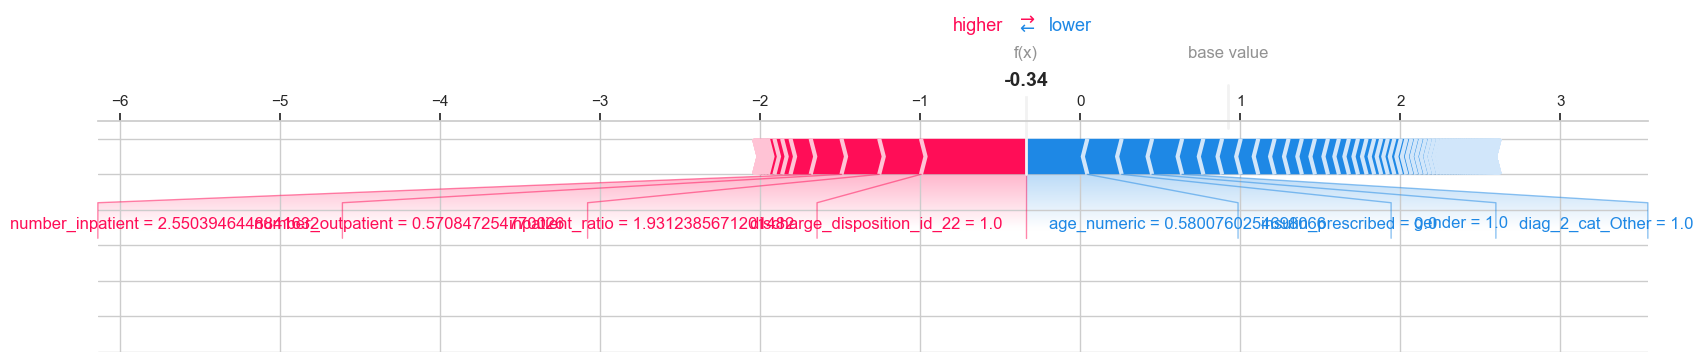

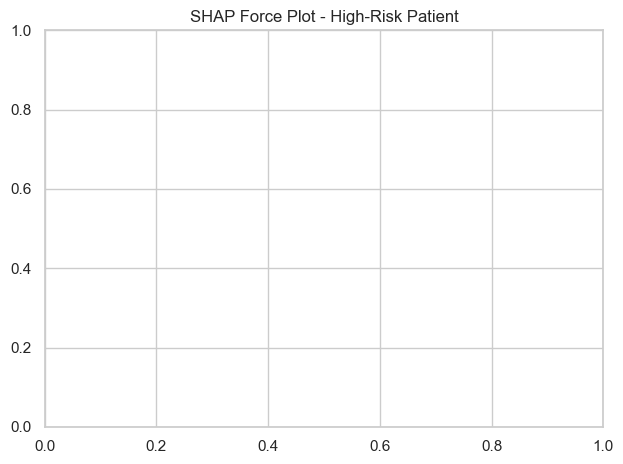

In [63]:
# Safely extract expected value (LightGBM binary returns shape-(1,) array)
ev = shap_explainer.expected_value
if isinstance(ev, np.ndarray):
    ev_scalar = float(ev.ravel()[0])
elif isinstance(ev, list):
    ev_scalar = float(ev[-1])
else:
    ev_scalar = float(ev)

shap.force_plot(
    ev_scalar,
    shap_vals_pos[patient_idx],
    X_shap_sample[patient_idx],
    feature_names=feature_names,
    matplotlib=True
)
plt.title("SHAP Force Plot - High-Risk Patient")
plt.tight_layout()
plt.show()


## 3. LIME — Local Explanations

In [64]:
# Build LIME explainer on the balanced training data
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_bal,
    feature_names=feature_names,
    class_names=['Not Readmitted', 'Readmitted <30d'],
    mode='classification',
    random_state=RANDOM_STATE,
    discretize_continuous=True
)

print('LIME explainer created.')
print(f'Training data shape: {X_train_bal.shape}')

LIME explainer created.
Training data shape: (95790, 207)


### 3.1 LIME — High-Risk Patient

Predicted probability (LIME): 0.4158


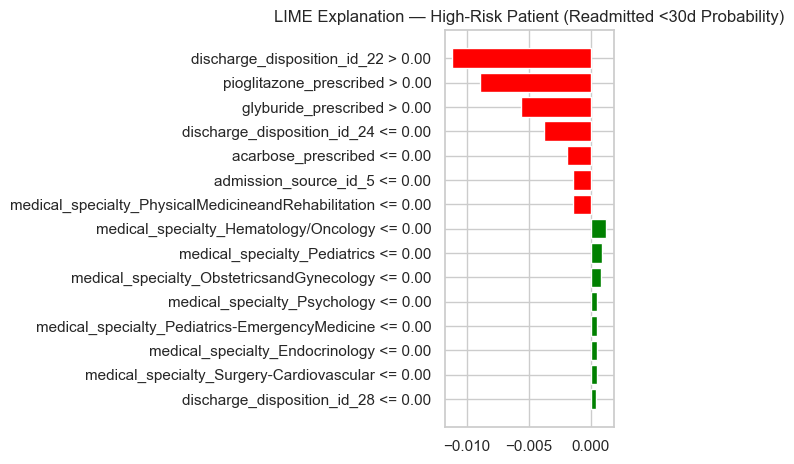

In [65]:
lime_exp_high = lime_explainer.explain_instance(
    data_row=X_shap_sample[patient_idx],
    predict_fn=model.predict_proba,
    num_features=15,
    num_samples=1000
)

print(f'Predicted probability (LIME): {lime_exp_high.predict_proba[1]:.4f}')
lime_exp_high.as_pyplot_figure(label=1)
plt.title('LIME Explanation — High-Risk Patient (Readmitted <30d Probability)')
plt.tight_layout()
plt.show()

### 3.2 LIME — Low-Risk Patient

Predicted probability (LIME): 0.0394


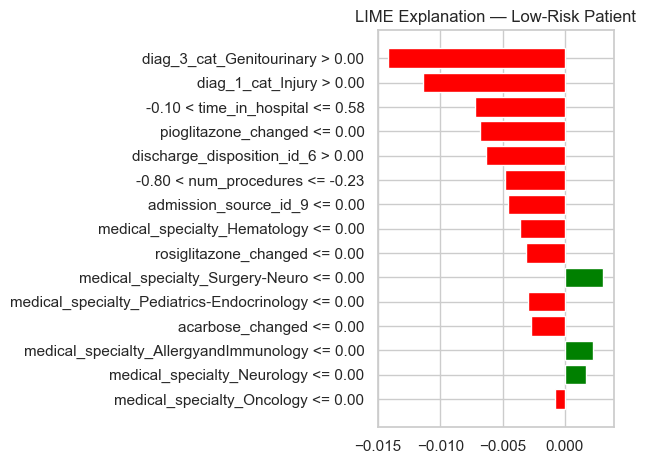

In [66]:
lime_exp_low = lime_explainer.explain_instance(
    data_row=X_shap_sample[low_risk_idx],
    predict_fn=model.predict_proba,
    num_features=15,
    num_samples=1000
)

print(f'Predicted probability (LIME): {lime_exp_low.predict_proba[1]:.4f}')
lime_exp_low.as_pyplot_figure(label=1)
plt.title('LIME Explanation — Low-Risk Patient')
plt.tight_layout()
plt.show()

### 3.3 LIME Aggregate — Top Features Across Multiple Patients

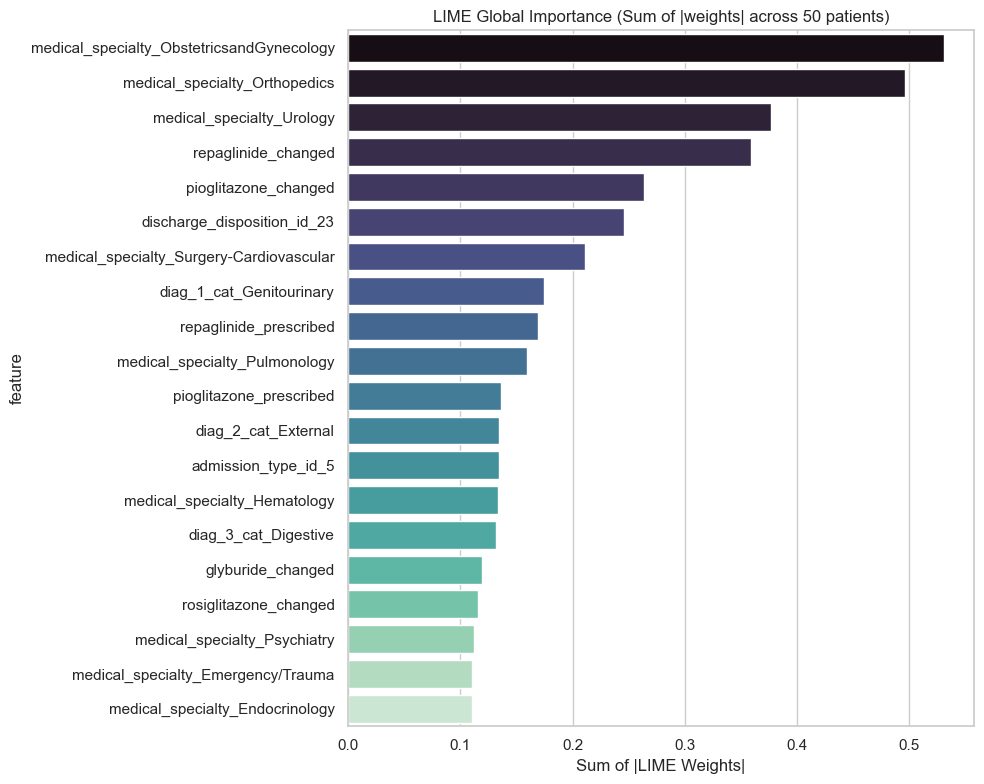

In [67]:
# Aggregate LIME weights across N_LIME_PATIENTS random patients
# Use word-boundary matching to avoid false substring matches
# (e.g. "change" matching inside "insulin_changed <= 0.50")
import re

N_LIME_PATIENTS = 50
np.random.seed(RANDOM_STATE)
lime_sample_idx = np.random.choice(X_shap_sample.shape[0], N_LIME_PATIENTS, replace=False)

lime_feature_weights = {feat: 0.0 for feat in feature_names}

# Build a lookup: escaped feature name -> original name
feat_patterns = {re.compile(r"(?<![\w])" + re.escape(fn) + r"(?![\w])"): fn
                 for fn in feature_names}

for idx in lime_sample_idx:
    exp = lime_explainer.explain_instance(
        X_shap_sample[idx], model.predict_proba,
        num_features=15, num_samples=500
    )
    for feat_desc, weight in exp.as_list(label=1):
        matched = False
        for pattern, fname in feat_patterns.items():
            if pattern.search(feat_desc):
                lime_feature_weights[fname] += abs(weight)
                matched = True
                break

lime_importance = pd.DataFrame([
    {"feature": k, "total_abs_weight": v} for k, v in lime_feature_weights.items()
]).sort_values("total_abs_weight", ascending=False).head(20)

plt.figure(figsize=(10, 8))
sns.barplot(data=lime_importance, x="total_abs_weight", y="feature", palette="mako")
plt.title(f"LIME Global Importance (Sum of |weights| across {N_LIME_PATIENTS} patients)")
plt.xlabel("Sum of |LIME Weights|")
plt.tight_layout()
plt.show()


## 4. SHAP vs LIME Comparison

In [68]:
# Compare top-15 features from SHAP and LIME
shap_top15 = shap_importance.head(15)[['feature', 'mean_abs_shap']].reset_index(drop=True)
shap_top15['shap_rank'] = range(1, 16)

lime_top15 = lime_importance.head(15)[['feature', 'total_abs_weight']].reset_index(drop=True)
lime_top15['lime_rank'] = range(1, 16)

comparison = shap_top15.merge(lime_top15, on='feature', how='outer')
print('SHAP vs LIME — Top Features Overlap:')
print(comparison[['feature', 'shap_rank', 'lime_rank']].to_string())

overlap = set(shap_top15['feature']) & set(lime_top15['feature'])
print(f'\nFeatures in both top-15: {len(overlap)} / 15')
print('Overlapping:', sorted(overlap))

SHAP vs LIME — Top Features Overlap:
                                      feature  shap_rank  lime_rank
0                         admission_type_id_5        NaN       13.0
1                                 age_numeric        1.0        NaN
2                      diag_1_cat_Circulatory       13.0        NaN
3                    diag_1_cat_Genitourinary        NaN        8.0
4                      diag_2_cat_Circulatory       12.0        NaN
5                         diag_2_cat_External        NaN       12.0
6                      diag_3_cat_Circulatory        7.0        NaN
7                         diag_3_cat_Diabetes       11.0        NaN
8                        diag_3_cat_Digestive        NaN       15.0
9                            diag_3_cat_Other       14.0        NaN
10                 discharge_disposition_id_1        3.0        NaN
11                discharge_disposition_id_22       10.0        NaN
12                discharge_disposition_id_23        NaN        6.0
13         

## 5. Save Explainability Artifacts

In [69]:
# Save SHAP explainer
with open(MODELS_DIR + "shap_explainer_case2.pkl", "wb") as f:
    pickle.dump(shap_explainer, f)

# LIME explainer cannot be pickled (contains internal lambda functions).
# Save its constructor config instead — recreate with lime.lime_tabular.LimeTabularExplainer(**config)
lime_config = {
    "training_data": X_train_bal,
    "feature_names": feature_names,
    "class_names": ["Not Readmitted", "Readmitted <30d"],
    "mode": "classification",
    "random_state": RANDOM_STATE,
    "discretize_continuous": True,
}
with open(MODELS_DIR + "lime_config_case2.pkl", "wb") as f:
    pickle.dump(lime_config, f)

# Safely extract scalar expected_value
# LightGBM binary: shape (1,) array; XGBoost binary: scalar or list[2]
ev = shap_explainer.expected_value
if isinstance(ev, np.ndarray):
    ev_scalar = float(ev.ravel()[0])
elif isinstance(ev, list):
    ev_scalar = float(ev[-1])
else:
    ev_scalar = float(ev)
print(f"Expected value (base rate): {ev_scalar:.4f}")

shap_artifacts = {
    "shap_values": shap_vals_pos,
    "X_shap_sample": X_shap_sample,
    "y_shap_sample": np.array(y_shap_sample),
    "feature_names": feature_names,
    "expected_value": ev_scalar,
}
with open(MODELS_DIR + "shap_values_case2.pkl", "wb") as f:
    pickle.dump(shap_artifacts, f)

print("Saved:")
print("  shap_explainer_case2.pkl")
print("  lime_config_case2.pkl  (constructor config, not explainer object)")
print("  shap_values_case2.pkl")


Expected value (base rate): 0.9216
Saved:
  shap_explainer_case2.pkl
  lime_config_case2.pkl  (constructor config, not explainer object)
  shap_values_case2.pkl


## 6. Deployment Utility Functions

In [70]:
def predict_readmission(patient_data: dict, model, preprocessor, feature_names):
    """
    Predict 30-day readmission risk for a single patient.
    
    Parameters
    ----------
    patient_data : dict
        Dictionary of feature_name -> value (before preprocessing).
    
    Returns
    -------
    dict with 'probability', 'risk_level', 'prediction'
    """
    df_patient = pd.DataFrame([patient_data], columns=feature_names)
    df_patient = df_patient.reindex(columns=feature_names, fill_value=0)
    X_proc = preprocessor.transform(df_patient)
    proba = model.predict_proba(X_proc)[0, 1]
    risk_level = 'High' if proba >= 0.5 else ('Medium' if proba >= 0.3 else 'Low')
    return {
        'probability': round(float(proba), 4),
        'risk_level': risk_level,
        'prediction': int(proba >= 0.5)
    }


def explain_with_shap(patient_data: dict, model, preprocessor, feature_names, shap_explainer):
    """
    Generate SHAP explanation for a single patient.
    Returns top feature contributions as a sorted list.
    """
    df_patient = pd.DataFrame([patient_data], columns=feature_names)
    df_patient = df_patient.reindex(columns=feature_names, fill_value=0)
    X_proc = preprocessor.transform(df_patient)
    sv = shap_explainer.shap_values(X_proc)
    if isinstance(sv, list):
        sv = sv[1]
    contributions = sorted(
        zip(feature_names, sv[0]),
        key=lambda x: abs(x[1]),
        reverse=True
    )
    return contributions[:15]


def explain_with_lime(patient_data: dict, model, preprocessor, feature_names, lime_explainer, num_features=15):
    """
    Generate LIME explanation for a single patient.
    Returns top feature contributions as a sorted list.
    """
    df_patient = pd.DataFrame([patient_data], columns=feature_names)
    df_patient = df_patient.reindex(columns=feature_names, fill_value=0)
    X_proc = preprocessor.transform(df_patient)
    exp = lime_explainer.explain_instance(
        X_proc[0], model.predict_proba,
        num_features=num_features, num_samples=1000
    )
    return exp.as_list(label=1)


print('Utility functions defined: predict_readmission, explain_with_shap, explain_with_lime')

Utility functions defined: predict_readmission, explain_with_shap, explain_with_lime


In [71]:
# Demo: run prediction and explanation on a test patient
test_patient_vec = X_test_proc[0]
test_patient_dict = dict(zip(feature_names, test_patient_vec))

result = predict_readmission(test_patient_dict, model, preprocessor, feature_names)
print('Prediction result:', result)

shap_contribs = explain_with_shap(test_patient_dict, model, preprocessor, feature_names, shap_explainer)
print('\nTop SHAP contributions:')
for feat, val in shap_contribs[:10]:
    direction = 'increases' if val > 0 else 'decreases'
    print(f'  {feat}: {val:+.4f} ({direction} readmission risk)')

Prediction result: {'probability': 0.087, 'risk_level': 'Low', 'prediction': 0}

Top SHAP contributions:
  num_prior_visits: +1.2120 (increases readmission risk)
  inpatient_ratio: +0.9119 (increases readmission risk)
  discharge_disposition_id_18: -0.5283 (decreases readmission risk)
  age_numeric: -0.5243 (decreases readmission risk)
  number_diagnoses: -0.4857 (decreases readmission risk)
  gender: -0.3232 (decreases readmission risk)
  time_in_hospital: -0.3076 (decreases readmission risk)
  discharge_disposition_id_1: -0.3004 (decreases readmission risk)
  medical_specialty_Unknown: -0.2308 (decreases readmission risk)
  total_meds_prescribed: -0.2289 (decreases readmission risk)
